# PolyGraphPy: A unified Python framework for atomistic simulation and machine learning-driven polymer design

This notebook demonstrates the workflow and capabilities of **PolyGraphPy**, a modular Python framework for atomistic simulation, molecular property prediction, and property-guided polymer generation. The analyses presented here replicate the results reported in the manuscript.

## 1. Environment Setup

We first import the required Python packages, including PyTorch, PyTorch Geometric, RDKit, DFTB+, and standard data analysis libraries.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

plt.rcParams.update({
    "text.usetex": False,            
    "mathtext.fontset": "cm",        
    "font.family": "serif",          
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
```

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole # Optional, for better rendering in notebooks

# The SMILES string provided
smiles_string = "CCOC(=O)/C=C/C1=C(C=CC(=C1)SCC2=CC=CC=C2)NC3=CC(=C(C=C3Cl)Cl)C"

# Generate the molecule object
mol = Chem.MolFromSmiles(smiles_string)

# Check if the molecule was parsed correctly
if mol:
    # Display the molecule
    # If running in a script, you might use: Draw.ShowMol(mol)
    # If in Jupyter, simply returning the object works, or use Draw.MolToImage
    img = Draw.MolToImage(mol, size=(600, 300))
    img.show() 
    # Or save it to a file
    img.save("molecule_structure.png")
    print("Molecule generated and saved as molecule_structure.png")
else:
    print("Error: Could not parse SMILES string.")

Molecule generated and saved as molecule_structure.png


## 2. Load and Inspect Monomer Dataset
We load the acrylate monomer dataset (9,626 entries) used in this study. We focus on key molecular descriptors such as molecular weight, XLogP, polar surface area, complexity, number of rotatable bonds, and heavy atom count.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",   
    "font.family": "serif",      
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# Load original acrylate monomer dataset
df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')

# Select relevant columns and rename SMILES column
df_original = df_original[['smiles', 'mw', 'xlogp', 'polararea', 'complexity', 'rotbonds', 'heavycnt']]
df_original = df_original.rename(columns={'smiles': 'smiles_A'})

# Display dataset size
print(f"Number of monomers in the dataset: {len(df_original)}")


Number of monomers in the dataset: 9626


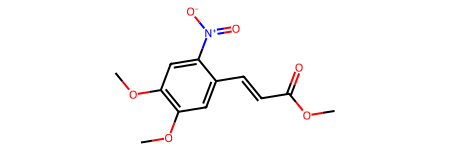

In [8]:
from rdkit import Chem

#smiles_string = 'CC1CC(=O)N(C1=O)C(=C)C(=O)OC'
#smiles_string = 'C1=CO[C@H]([C@H]2[C@@H]1[C@@H]([C@H]3[C@@]2(O3)CO)OC(=O)/C=C/C4=CC(=C(C=C4)O)O)O[C@H]5[C@@H]([C@H]([C@@H]([C@H](O5)CO)O)O)O'
#smiles_string = 'CCCCOC(=O)C=C.CC(=C)C(=O)O.CC(=C)C(=O)OC'
#smiles_string = 'COC1=C(C=CC(=C1)/C=C/C(=O)OCCC2=CC=CC=C2)O'
#smiles_string = 'CCCCCCCCCOC(=O)C=C' # - OK
#smiles_string = r'CCOC(=O)/C=C\SC1=NC=CC=N1'
#smiles_string = 'C[N+](C)(C)CCOC(=O)/C=C/C1=CN=CN1'
#smiles_string = 'CCOC(=O)/C(=C/NC1=CC=C(C=C1)F)/C#N'
#smiles_string = 'CC1CCC(C(C1)OC(=O)C=C)C(C)(C)C2=CC=CC=C2'
#smiles_string = 'C=CC(=O)OCCC(=O)O' # - OK
smiles_string = 'COC1=C(C=C(C(=C1)C=CC(=O)OC)[N+](=O)[O-])OC'
#smiles_string = 'CC(=O)[C@@H]1CCCC[C@@H]2[C@]1(OC(O2)(C)C)C=CC(=O)OC'

mol = Chem.MolFromSmiles(smiles_string)
mol

In [7]:
#smiles_string = 'COC1=C(C=C(C(=C1)C=CC(=O)OC)[N+](=O)[O-])OC'
Chem.MolToSmiles(mol)

'COC(=O)C=C[C@@]12OC(C)(C)O[C@@H]1CCCC[C@H]2C(C)=O'

## 3. Distribution of Molecular Descriptors

To better understand the acrylate monomer dataset, we visualize the distributions of key molecular descriptors using histograms. These descriptors provide insight into the chemical space and structural diversity of the monomers.

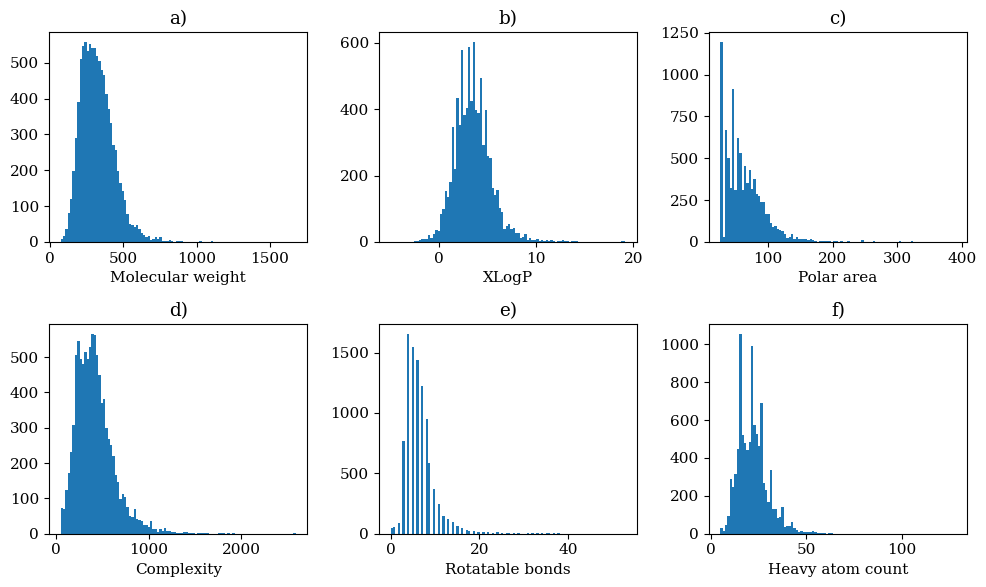

In [2]:
# Set up figure
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()  # Flatten for easy iteration

# Define descriptors and labels
descriptors = ['mw', 'xlogp', 'polararea', 'complexity', 'rotbonds', 'heavycnt']
labels = ['Molecular weight', 'XLogP', 'Polar area', 'Complexity', 'Rotatable bonds', 'Heavy atom count']
titles = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

# Plot histograms
for ax, desc, label, title in zip(axes, descriptors, labels, titles):
    ax.hist(df_original[desc], bins=100)
    ax.set_xlabel(label)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig('../figures/Figure_12.pdf')

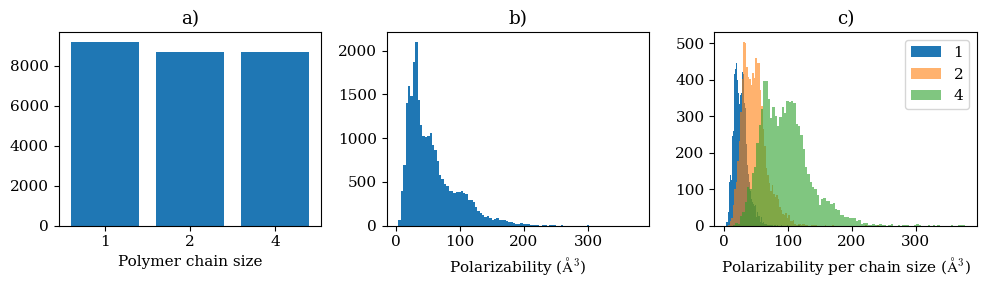

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_chain_size = df_homopolymer.groupby('chain_size').count().reset_index()

fig = plt.figure(figsize=(10, 3))

# ==========================================
# Subplot 1: Bar Chart (Fixed Spacing)
# ==========================================
plt.subplot(1, 3, 1)

# 1. Define arbitrary equidistant positions (0, 1, 2)
x_positions = range(len(df_chain_size)) 

# 2. Plot the data at these positions
plt.bar(x_positions, df_chain_size['id_A'])

# 3. Rename the ticks to display the actual chain sizes
# We assume the rows correspond to sizes 1, 2, 4 in that order
plt.xticks(x_positions, ['1', '2', '4'])

plt.xlabel('Polymer chain size')
plt.title('a)')

# ==========================================
# Subplot 2: Histogram
# ==========================================
plt.subplot(1, 3, 2)
plt.hist(df_homopolymer['static_polarizability'] * 0.14818471, bins=100)

# Added unit in LaTeX format
plt.xlabel(r'Polarizability ($\mathrm{\AA}^3$)') 
plt.title('b)')

# ==========================================
# Subplot 3: Overlaid Histogram
# ==========================================
plt.subplot(1, 3, 3)
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 0]['static_polarizability'] * 0.14818471, bins=100, alpha=1, label='1')
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 1]['static_polarizability'] * 0.14818471, bins=100, alpha=0.6, label='2')
plt.hist(df_homopolymer[df_homopolymer['chain_size'] == 2]['static_polarizability'] * 0.14818471, bins=100, alpha=0.6, label='4')

# Added unit in LaTeX format
plt.xlabel(r'Polarizability per chain size ($\mathrm{\AA}^3$)')
plt.legend()
plt.title('c)')

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_13.pdf')

## 4. Static Polarizability of Monomers and Homopolymers

The atomistic simulation module of **PolyGraphPy** computes quantum mechanical properties using DFTB+, including the **static polarizability** of monomers and short polymer chains.  

Here, we load the dataset containing monomer/homopolymer (chain sizes 0, 1 and 2) and copolymer polarizabilities. The first contains 26,582 entries, the latter 41,835 contains with the following key columns:  

- `id_A` / `id_B`: ID of each monomer
- `smiles_A` / `smiles_B`: SMILES representation of monomers  
- `chain_size`: Length of the polymer chain  
- `static_polarizability`: Computed polarizability in atomic units  
- `type`: Indicates whether the entry is a monomer, homopolymer, or copolymer  

Explanation:
- Missing values in id_B and smiles_B indicate entries corresponding to monomers or homopolymers.
- These datasets are used to analyze property distributions and validate GNN predictions.

In [4]:
# Load polarizability data for monomers/homopolymers and copolymers
df_homopolymer = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/polarizability_data_copoly.csv')

### 4.1 Visualizing Polarizability Distributions
We visualize the distribution of static polarizabilities using histograms and a boxplot. To avoid outliers affecting visualization, we exclude the top 15 sorted values.

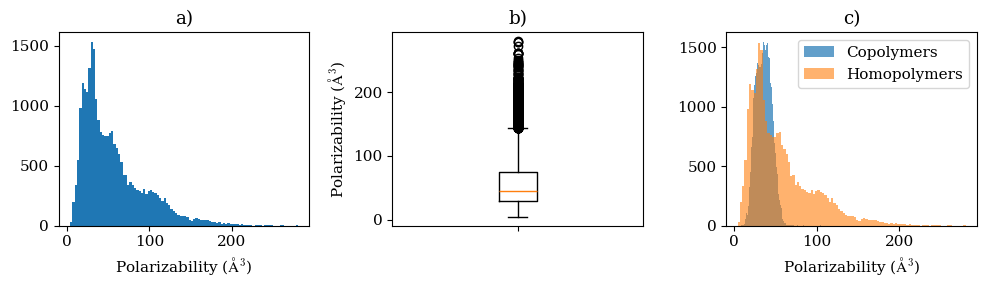

In [5]:
# Prepare figure
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# Subplot (a): Histogram of copolymer polarizabilities
axes[0].hist(df_homopolymer['static_polarizability'].sort_values()[:-15] * 0.14818471, bins=100)
axes[0].set_xlabel(r'Polarizability ($\mathrm{\AA}^3$)')
axes[0].set_title('a)')

# Subplot (b): Boxplot of copolymer polarizabilities
axes[1].boxplot(df_homopolymer['static_polarizability'].sort_values()[:-15] * 0.14818471)
axes[1].set_ylabel(r'Polarizability ($\mathrm{\AA}^3$)')
axes[1].set_title('b)')
axes[1].set_xticklabels([''])

# Subplot (c): Comparison histogram between copolymers and homopolymers
axes[2].hist(df_copolymer['static_polarizability'].sort_values()[:-15] * 0.14818471, bins=100, alpha=0.7, label='Copolymers')
axes[2].hist(df_homopolymer['static_polarizability'].sort_values()[:-15] * 0.14818471, bins=100, alpha=0.6, label='Homopolymers')
axes[2].set_xlabel(r'Polarizability ($\mathrm{\AA}^3$)')
axes[2].set_title('c)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Save figure
fig.savefig('../figures/Figure_14.pdf')


## 5. GNN Training Statistics

We trained a **GNN** model to predict static polarizabilities for monomers, homopolymers, and copolymers. Here, we visualize the **training and validation losses** over epochs for both datasets.

Explanation:
- The plots show mean squared error (MSE) loss for training and validation datasets over each epoch.
- Subplot (a) represents monomers and homopolymers; subplot (b) represents copolymers.

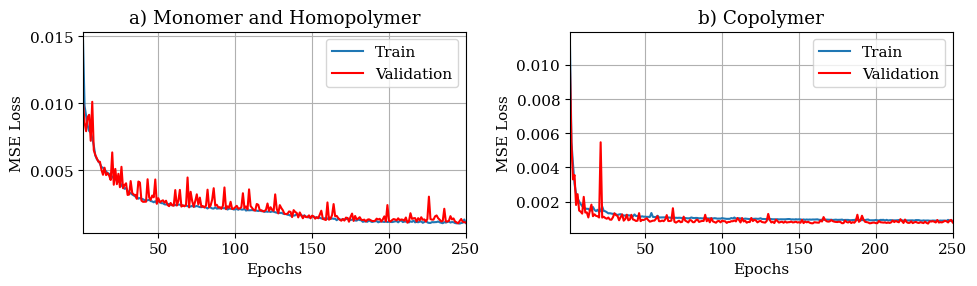

In [6]:
# Load training statistics
df_training_homopolymer = pd.read_csv('../polygraphpy/data/gnn_output/training_statistics.csv')
df_training_copolymer = pd.read_csv('../polygraphpy/data/gnn_output_copoly/training_statistics_copoly.csv')

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Subplot (a): Monomer and homopolymer training
axes[0].plot(df_training_homopolymer['epoch'] + 1, df_training_homopolymer['train_loss'], label='Train')
axes[0].plot(df_training_homopolymer['epoch'] + 1, df_training_homopolymer['val_loss'], 'r', label='Validation')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlim([1, df_training_homopolymer['epoch'].max() + 1])
axes[0].grid(True)
axes[0].legend()

# Subplot (b): Copolymer training
axes[1].plot(df_training_copolymer['epoch'] + 1, df_training_copolymer['train_loss'], label='Train')
axes[1].plot(df_training_copolymer['epoch'] + 1, df_training_copolymer['val_loss'], 'r', label='Validation')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title('b) Copolymer')
axes[1].set_xlim([1, df_training_copolymer['epoch'].max() + 1])
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_15.pdf")

## 6. GNN Predictions vs. Ground Truth

We evaluate the performance of the GNN model by comparing predicted static polarizabilities against the original ground truth values for both monomers/homopolymers and copolymers.  

Since the model outputs were scaled during training using MinMaxScaler, we first **rescale predictions and ground truths** back to the original polarizability range.

Explanation:
- Each point represents one molecule (monomer, homopolymer, or copolymer).
- The red line represents perfect prediction (y = x). Points near this line indicate accurate predictions.
- Scatter density and deviation from the line provide a visual estimate of model performance.
- Rescaling ensures predictions are directly comparable to computed polarizabilities.
- These plots demonstrate that the GNN effectively captures the quantum mechanical property trends across both datasets.


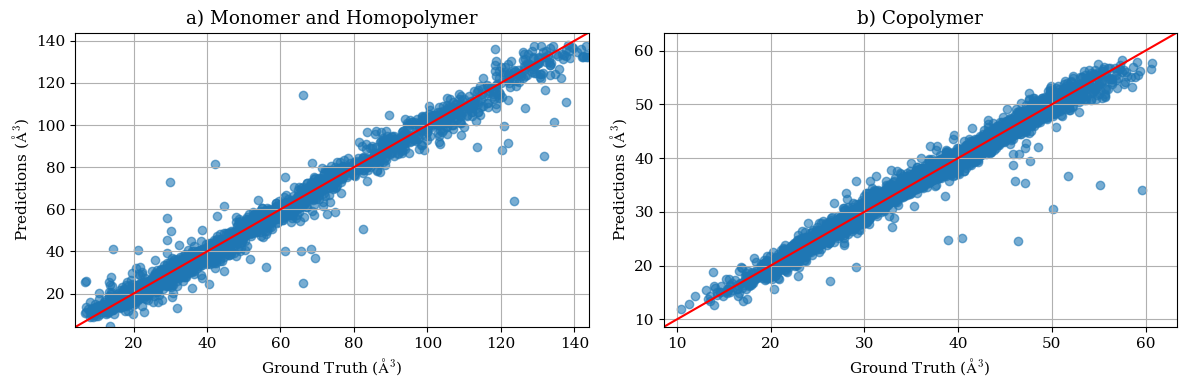

In [7]:
# Load prediction and ground truth datasets
df_pred_homopoly = pd.read_csv('../polygraphpy/data/gnn_output/df_results.csv')
df_original_homopoly = pd.read_csv('../polygraphpy/data/gnn_output/scaled_output.csv')
df_pred_copoly = pd.read_csv('../polygraphpy/data/gnn_output_copoly/df_results.csv')
df_original_copoly = pd.read_csv('../polygraphpy/data/gnn_output_copoly/scaled_output_copoly.csv')

# Retrieve original min and max for rescaling
min_max_homo = (df_original_homopoly['static_polarizability_original'].min() * 0.14818471,
                df_original_homopoly['static_polarizability_original'].max() * 0.14818471) 
min_max_copoly = (df_original_copoly['static_polarizability_original'].min() * 0.14818471,
                  df_original_copoly['static_polarizability_original'].max() * 0.14818471)

# Rescale predictions and ground truths
df_pred_homopoly['y_original'] = df_pred_homopoly['y'] * (min_max_homo[1] - min_max_homo[0]) + min_max_homo[0]
df_pred_homopoly['pred_original'] = df_pred_homopoly['pred'] * (min_max_homo[1] - min_max_homo[0]) + min_max_homo[0]

df_pred_copoly['y_original'] = df_pred_copoly['y'] * (min_max_copoly[1] - min_max_copoly[0]) + min_max_copoly[0]
df_pred_copoly['pred_original'] = df_pred_copoly['pred'] * (min_max_copoly[1] - min_max_copoly[0]) + min_max_copoly[0]

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot (a): Monomer and homopolymer
axes[0].scatter(df_pred_homopoly['y_original'], df_pred_homopoly['pred_original'], alpha=0.6)
axes[0].plot([min_max_homo[0], min_max_homo[1]], [min_max_homo[0], min_max_homo[1]], 'r')
axes[0].set_xlabel(r"Ground Truth ($\mathrm{\AA}^3$)")
axes[0].set_ylabel(r"Predictions ($\mathrm{\AA}^3$)")
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlim(min_max_homo)
axes[0].set_ylim(min_max_homo)
axes[0].grid(True)

# Subplot (b): Copolymer
axes[1].scatter(df_pred_copoly['y_original'], df_pred_copoly['pred_original'], alpha=0.6)
axes[1].plot([min_max_copoly[0], min_max_copoly[1]], [min_max_copoly[0], min_max_copoly[1]], 'r')
axes[1].set_xlabel(r"Ground Truth ($\mathrm{\AA}^3$)")
axes[1].set_ylabel(r"Predictions ($\mathrm{\AA}^3$)")
axes[1].set_title('b) Copolymer')
axes[1].set_xlim(min_max_copoly)
axes[1].set_ylim(min_max_copoly)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_16.pdf")

## 7. Uncertainty Estimation Using Monte Carlo Dropout

To quantify prediction uncertainty, we perform **Monte Carlo Dropout** on the validation set. This involves running the GNN model multiple times with dropout enabled during inference, producing a distribution of predictions for each molecule.  

Here, we visualize the **ensemble of predictions** for both monomers/homopolymers and copolymers.

Explanation:
- Each black line represents a single Monte Carlo dropout run, showing variability in predictions.
- The blue dotted line shows the mean of all 100 runs, providing a stable estimate of the predicted polarizability.
- The red line is the ground truth. Close alignment between the mean and ground truth indicates good predictive performance.
- Variability among the black lines reflects the model’s uncertainty in its predictions.
- Using Monte Carlo Dropout allows estimation of epistemic uncertainty in molecular property predictions, useful for guiding generative design or identifying high-confidence predictions.


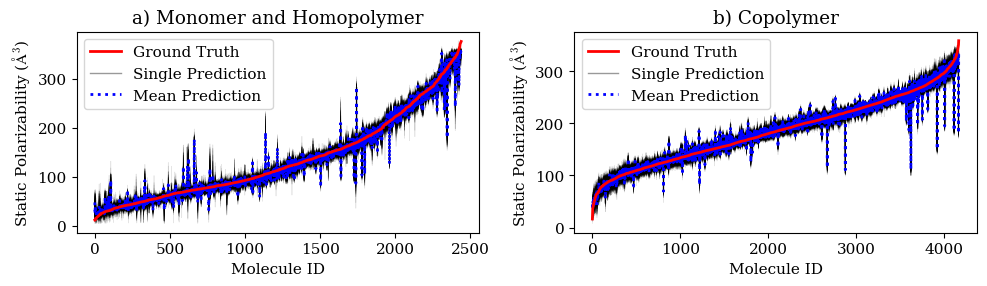

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the RAW data to get scaling parameters (Min/Max)
df_raw = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
raw_vals = df_raw['static_polarizability']

# Calculate global Min and Max from the original dataset (assuming MinMax scaling was used)
RAW_MIN = raw_vals.min()
RAW_MAX = raw_vals.max()
BOHR_TO_ANGSTROM3 = 0.14818471

def process_data(df_scaled):
    """
    1. Unscales data (assuming MinMax 0-1 scaling).
    2. Converts from Bohr^3 to Angstrom^3.
    """
    # Inverse MinMax: x_raw = x_scaled * (max - min) + min
    df_unscaled = df_scaled * (RAW_MAX - RAW_MIN) + RAW_MIN
    
    # Unit Conversion
    df_final = df_unscaled * BOHR_TO_ANGSTROM3
    return df_final

# 2. Load Monte Carlo Dropout results
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_copolymer.csv')

# 3. Apply transformation to the entire dataframes (predictions + ground truth)
df_homo_final = process_data(df_homopolymer)
df_copo_final = process_data(df_copolymer)

# 4. Set up figure
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# --- Helper function for consistent plotting ---
def plot_uq(ax, df, title):
    # Plot individual MC runs (gray/black lines)
    # We iterate a subset if 100 is too heavy, but here we do all 100
    for i in range(100):
        col_name = f'run_{i}'
        if col_name in df.columns:
            ax.plot(df.index, df[col_name], color='k', alpha=0.1, linewidth=0.5)

    # Calculate Mean Prediction across runs (excluding ground truth 'y')
    pred_cols = [c for c in df.columns if 'run_' in c]
    mean_pred = df[pred_cols].mean(axis=1)

    # Plot specific lines
    # 1. A single run example (optional, but requested in original code)
    line_pred, = ax.plot(df.index, df['run_0'], 'k', linewidth=1, alpha=0.4, label='Predictions (Runs)')
    
    # 2. Mean Prediction
    line_mean, = ax.plot(df.index, mean_pred, ':b', linewidth=2, label='Mean Prediction')
    
    # 3. Ground Truth
    line_gt, = ax.plot(df.index, df['y'], 'r', linewidth=2, label='Ground Truth')

    # Formatting
    ax.set_title(title)
    ax.set_xlabel("Molecule ID")
    ax.set_ylabel(r"Static Polarizability ($\mathrm{\AA}^3$)")
    
    # Remove manual y-ticks to let matplotlib auto-scale to the new physical range
    # ax.set_yticks(...) 
    
    return [line_gt, line_pred, line_mean]

# --- Subplot (a): Monomer and Homopolymer ---
lines_a = plot_uq(axes[0], df_homo_final, 'a) Monomer and Homopolymer')
axes[0].legend(lines_a, ['Ground Truth', 'Single Prediction', 'Mean Prediction'])

# --- Subplot (b): Copolymer ---
lines_b = plot_uq(axes[1], df_copo_final, 'b) Copolymer')
axes[1].legend(lines_b, ['Ground Truth', 'Single Prediction', 'Mean Prediction'])

plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../figures/Figure_17.pdf")

## 8. Molecular Prediction Uncertainty: Standard Deviation

To quantify the **uncertainty of predictions** for each molecule, we compute the **standard deviation** across the 100 Monte Carlo Dropout runs.  
Higher standard deviation indicates higher model uncertainty for a given molecule.

Explanation:
- Each point represents the standard deviation of 100 Monte Carlo Dropout runs for a single molecule.
- Large deviations indicate molecules where the model is less confident.
- This plot complements the ensemble prediction visualization, providing a quantitative measure of uncertainty across the dataset.
- Such metrics are valuable for identifying molecules that may require additional atomistic simulations or experimental validation.


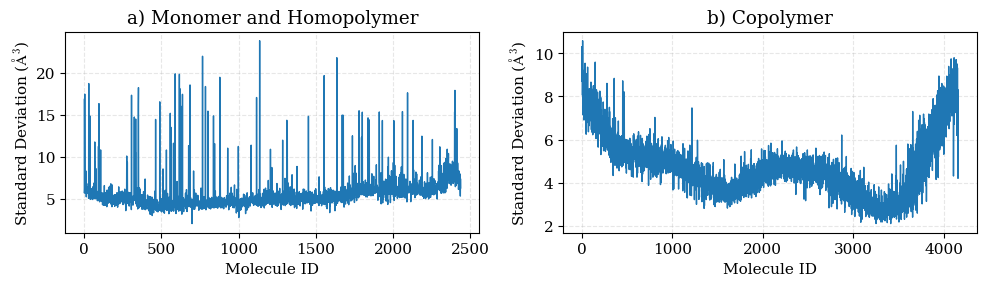

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data & Get Scaling Factors
# We need the range from the raw data to unscale the std dev
df_raw = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
raw_vals = df_raw['static_polarizability']

RAW_RANGE = raw_vals.max() - raw_vals.min()
BOHR_TO_ANGSTROM3 = 0.14818471

# The total factor to convert scaled std -> physical std (Angstrom^3)
STD_SCALE_FACTOR = RAW_RANGE * BOHR_TO_ANGSTROM3

# 2. Load Monte Carlo Dropout results
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_copolymer.csv')

# 3. Compute Unscaled Standard Deviations
# We calculate the std of the scaled data first, then apply the factor
std_homo = df_homopolymer.drop(columns='y').std(axis=1) * STD_SCALE_FACTOR
std_copo = df_copolymer.drop(columns='y').std(axis=1) * STD_SCALE_FACTOR

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Subplot (a): Monomer and homopolymer
axes[0].plot(df_homopolymer.index, std_homo, linewidth=1, color='#1f77b4') # Added color for clarity
axes[0].set_title('a) Monomer and Homopolymer')
axes[0].set_xlabel("Molecule ID")
axes[0].set_ylabel(r"Standard Deviation ($\mathrm{\AA}^3$)")
axes[0].grid(True, linestyle='--', alpha=0.3)

# Subplot (b): Copolymer
axes[1].plot(df_copolymer.index, std_copo, linewidth=1, color='#1f77b4')
axes[1].set_title('b) Copolymer')
axes[1].set_xlabel("Molecule ID")
axes[1].set_ylabel(r"Standard Deviation ($\mathrm{\AA}^3$)")
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_18.pdf")

## 9. Distribution of Prediction Errors

To assess the accuracy and reliability of the GNN model, we analyze the distribution of prediction metrics across the validation set:

- **MAPE (%)**: Mean Absolute Percentage Error  
- **R²**: Coefficient of determination  
- **MSE (%)**: Mean Squared Error, scaled by 100 for visualization  

We visualize the distributions using **Kernel Density Estimation (KDE)** plots for both monomer/homopolymer and copolymer datasets.

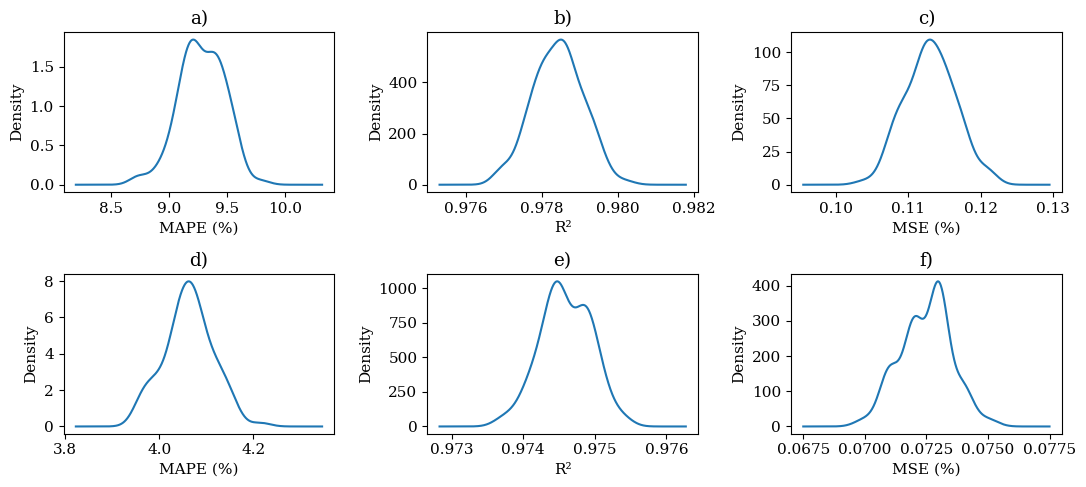

In [13]:
# Load error metrics
df_homopolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_error_homopolymer.csv')
df_copolymer = pd.read_csv('../polygraphpy/data/uq_analysis/results_uq_error_copolymer.csv')

# Scale MSE for visualization
df_homopolymer['mse'] = 100 * df_homopolymer['mse']
df_copolymer['mse'] = 100 * df_copolymer['mse']

# Set up figure
fig, axes = plt.subplots(2, 3, figsize=(11, 5))

# Monomer and homopolymer KDEs
df_homopolymer['mape'].plot.kde(ax=axes[0, 0])
axes[0, 0].set_xlabel('MAPE (%)'); axes[0, 0].set_title('a)')

df_homopolymer['r2'].plot.kde(ax=axes[0, 1])
axes[0, 1].set_xlabel('R²'); axes[0, 1].set_title('b)')

df_homopolymer['mse'].plot.kde(ax=axes[0, 2])
axes[0, 2].set_xlabel('MSE (%)'); axes[0, 2].set_title('c)')

# Copolymer KDEs
df_copolymer['mape'].plot.kde(ax=axes[1, 0])
axes[1, 0].set_xlabel('MAPE (%)'); axes[1, 0].set_title('d)')

df_copolymer['r2'].plot.kde(ax=axes[1, 1])
axes[1, 1].set_xlabel('R²'); axes[1, 1].set_title('e)')

df_copolymer['mse'].plot.kde(ax=axes[1, 2])
axes[1, 2].set_xlabel('MSE (%)'); axes[1, 2].set_title('f)')

plt.tight_layout()
plt.show()

# Save figure as PDF
fig.savefig("../figures/Figure_19.pdf")

## 10. Analysis of Genetic Algorithm-Based Monomer Generation

To evaluate the performance of the **Genetic Algorithm (GA) generative model**, we analyze the predicted fitness values relative to their target polarizabilities.  
This analysis includes:

1. **Prediction vs. Ground Truth** for property-guided generation.  
2. **Fitness distributions** across different polarizabilities using a kernel density estimate (KDE) heatmap.

Explanation:
- Subplot (a): Scatter plot of GA-generated molecules’ predicted polarizabilities versus target polarizabilities with the original range. The red line indicates perfect agreement (y = x). High R² confirms the GA effectively optimizes molecules toward the target property.
- Subplot (b): KDE heatmap shows the distribution of fitness scores across polarizabilities. Ligther regions indicate higher density of solutions. This visualization highlights the property-guided exploration capability of the GA.
- Normalization and interpolation ensure smooth, interpretable visualization for publication.
- Together, these plots demonstrate both accuracy and diversity in the GA-generated molecular ensemble.

R² Score: 0.9990263283508327


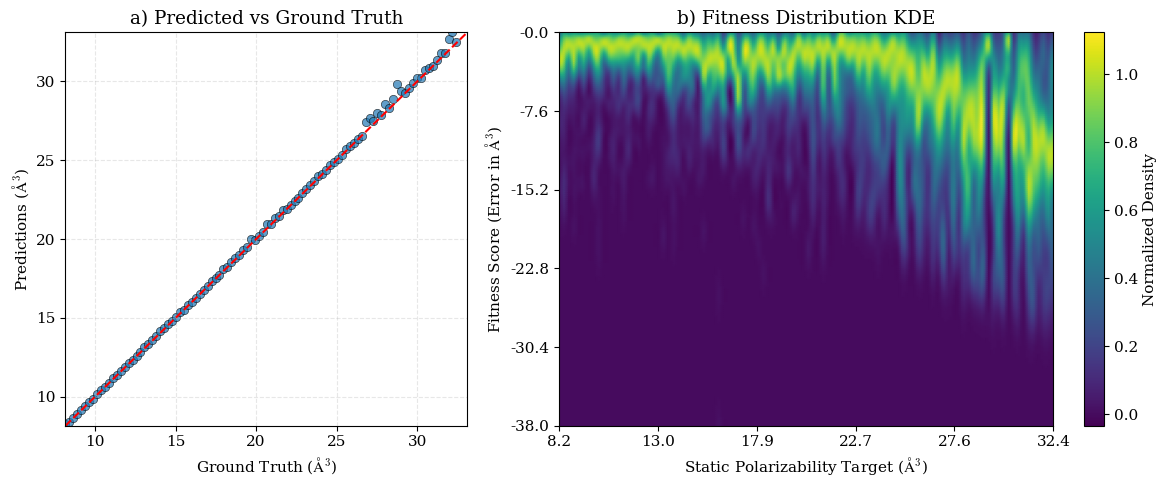

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from matplotlib import gridspec
from scipy.ndimage import zoom

# Constants
BOHR_TO_ANGSTROM3 = 0.14818471

# 1. Load Data
df = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original[df_original['chain_size'] == 0]

# 2. Fit Scaler to Original Data (to capture Range and Min/Max)
raw_values = df_original['static_polarizability'].values.reshape(-1, 1)
scaler = MinMaxScaler().fit(raw_values)
RAW_RANGE = raw_values.max() - raw_values.min()

# 3. Process Data for Scatter Plot (Subplot A)
# Group by target (scaled) and find best fitness (scaled error)
best_fitness = df.groupby('static_polarizability')['fitness'].max()
targets_unique_scaled = df["static_polarizability"].unique()

# Calculate Predictions in Scaled Space: Pred = Target - Fitness
# (Assuming fitness here acts as the error term: target - pred = fitness)
pred_scaled = targets_unique_scaled - best_fitness.values

# Unscale to Physical Units (Bohr^3 -> Angstrom^3)
# 1. Inverse transform returns Bohr^3
# 2. Multiply by factor to get Angstrom^3
targets_phys = scaler.inverse_transform(targets_unique_scaled.reshape(-1, 1)).flatten() * BOHR_TO_ANGSTROM3
pred_phys = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten() * BOHR_TO_ANGSTROM3

# Sort for cleaner plotting
sort_idx = np.argsort(targets_phys)
targets_sorted = targets_phys[sort_idx]
pred_sorted = pred_phys[sort_idx]

# 4. Create Figure
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 2]) 
ax_scatter = plt.subplot(gs[0])
ax_heatmap = plt.subplot(gs[1])

# --- Subplot (a): Predicted vs. Ground Truth (Physical Units) ---
ax_scatter.scatter(targets_sorted, pred_sorted, alpha=0.7, edgecolors='k', linewidth=0.5)

# Diagonal Line (Perfect Prediction)
min_val = min(targets_sorted.min(), pred_sorted.min())
max_val = max(targets_sorted.max(), pred_sorted.max())
ax_scatter.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

ax_scatter.set_xlim([min_val, max_val])
ax_scatter.set_ylim([min_val, max_val])
ax_scatter.set_xlabel(r"Ground Truth ($\mathrm{\AA}^3$)")
ax_scatter.set_ylabel(r"Predictions ($\mathrm{\AA}^3$)")
ax_scatter.set_title("a) Predicted vs Ground Truth")
ax_scatter.grid(True, linestyle='--', alpha=0.3)

# Print R2 score for verification
print("R² Score:", r2_score(targets_sorted, pred_sorted))

# --- Subplot (b): KDE Heatmap (Physical Units) ---
groups = df.groupby('static_polarizability')
polar_values_scaled = sorted(groups.groups.keys())

# Define grid for heatmap
n_molecules = 100
kde_matrix = np.zeros((n_molecules, len(polar_values_scaled)))

# We need to determine the range of Fitness in Physical Units for the Y-axis
# Fitness (Scaled Delta) -> Fitness (Physical Delta) = Fitness * Range * UnitFactor
fitness_min_scaled = df['fitness'].min()
fitness_max_scaled = df['fitness'].max()

# Create a linspace for the Y-axis in Scaled units first (for KDE calculation)
fitness_grid_scaled = np.linspace(fitness_min_scaled, fitness_max_scaled, n_molecules)

for i, polar in enumerate(polar_values_scaled):
    # Get fitness values for this target
    fitness_vals = groups.get_group(polar)['fitness'].values
    
    # Compute KDE on the scaled fitness values
    kde = gaussian_kde(fitness_vals, bw_method=0.3)
    kde_values = kde(fitness_grid_scaled)
    kde_matrix[:, i] = kde_values / kde_values.max()  # Normalize column-wise

# Interpolate matrix for smoothness
n_interp = 200
zoom_factor = n_interp / kde_matrix.shape[0] 
interpolated_matrix = zoom(kde_matrix, zoom=zoom_factor, order=3)

# Plot Heatmap
pcm = ax_heatmap.pcolormesh(interpolated_matrix, shading='gouraud', cmap='viridis')

ax_heatmap.set_xlabel(r'Static Polarizability Target ($\mathrm{\AA}^3$)')
ax_heatmap.set_ylabel(r'Fitness Score (Error in $\mathrm{\AA}^3$)')
ax_heatmap.set_title('b) Fitness Distribution KDE')

# --- Fix Ticks to show Physical Units ---

# X-Axis Ticks (Targets)
n_x_ticks = 6
# Get physical values for the X-axis limits
x_start_phys = scaler.inverse_transform([[min(polar_values_scaled)]])[0][0] * BOHR_TO_ANGSTROM3
x_end_phys   = scaler.inverse_transform([[max(polar_values_scaled)]])[0][0] * BOHR_TO_ANGSTROM3
# Create label positions and values
x_tick_locs = np.linspace(0, interpolated_matrix.shape[1]-1, n_x_ticks)
x_tick_labels = np.linspace(x_start_phys, x_end_phys, n_x_ticks)
ax_heatmap.set_xticks(x_tick_locs)
ax_heatmap.set_xticklabels(np.round(x_tick_labels, 1))

# Y-Axis Ticks (Fitness/Error)
n_y_ticks = 6
# Convert Scaled Fitness limits to Physical Error
y_start_phys = fitness_min_scaled * RAW_RANGE * BOHR_TO_ANGSTROM3
y_end_phys   = fitness_max_scaled * RAW_RANGE * BOHR_TO_ANGSTROM3
# Create label positions and values
y_tick_locs = np.linspace(0, interpolated_matrix.shape[0]-1, n_y_ticks)
y_tick_labels = np.linspace(y_start_phys, y_end_phys, n_y_ticks)
ax_heatmap.set_yticks(y_tick_locs)
ax_heatmap.set_yticklabels(np.round(y_tick_labels, 2))

plt.colorbar(pcm, ax=ax_heatmap, label='Normalized Density')

plt.tight_layout()
plt.show()

# Save figure
fig.savefig("../figures/Figure_21.pdf", transparent=False)

## 11. Novelty Assessment of Generated Molecules

To evaluate the **novelty** of the generated molecules, we check which SMILES strings are **already present** in the original acrylate dataset.  
This provides insight into whether the generative model proposes **new chemical structures** or reproduces existing ones.

In [18]:
import pandas as pd

# Load GA-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/ga_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers in original dataset (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# Remove duplicates from generated molecules
df_unique = df_generated.drop_duplicates(subset='smiles')

# Compute fraction of generated molecules present in original dataset
fraction_present = len(df_unique[df_unique['smiles'].isin(df_original['smiles_A'])]) / len(df_unique)
novelty_fraction = 1 - fraction_present

print(f"Fraction of generated molecules that are novel: {novelty_fraction:.4f}")

Fraction of generated molecules that are novel: 0.9961


## 12. Analysis of GPT-Based Generative Model

We assess the GPT-based generative model in three aspects:

1. **Uniqueness** – fraction of generated SMILES that are distinct.  
2. **Novelty** – fraction of generated molecules not present in the original dataset.  
3. **Coverage** – polarizability values explored by the generated molecules.

Explanation:
- Uniqueness ensures the GPT model is not generating repeated molecules.
- Novelty measures how many generated molecules are new compared to the original dataset.
- Coverage examines the distribution of target polarizabilities to verify whether the model explores the desired property space comprehensively.
- Missing polarizability values indicate gaps in property-guided generation, which could guide further model refinement or sampling.


In [19]:
import pandas as pd
import numpy as np

# Load GPT-generated molecules and original dataset
df_generated = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

# Consider only monomers (chain_size == 0)
df_original = df_original[df_original['chain_size'] == 0]

# --- 1. Uniqueness ---
n_unique = len(df_generated['smiles_A'].drop_duplicates())
total_generated = len(df_generated['smiles_A'])
uniqueness_fraction = n_unique / total_generated
print(f"Fraction of unique generated molecules: {uniqueness_fraction:.4f}")

# --- 2. Novelty ---
novelty_fraction = 1 - df_generated['smiles_A'].drop_duplicates().isin(df_original['smiles_A']).sum() / n_unique
print(f"Fraction of novel molecules: {novelty_fraction:.4f}")

# --- 3. Polarizability Coverage ---
df_grouped = df_generated.groupby('static_polarizability').count()['smiles_A'].reset_index()
polarizability_series = pd.Series(np.linspace(0, 1, 200)).round(4)

# Identify polarizability bins not represented in generated dataset
missing_polarizabilities = polarizability_series[~polarizability_series.isin(df_generated['static_polarizability'].round(4))].values
print("Missing polarizabilities (not covered by generated molecules):", missing_polarizabilities)

Fraction of unique generated molecules: 1.0000
Fraction of novel molecules: 0.8630
Missing polarizabilities (not covered by generated molecules): [0.0804 0.5578 0.5678 0.6884 0.8191]


## 13. Visualization of GPT-Based Generation Accuracy

We evaluate the GPT-based model's ability to generate molecules with target polarizabilities by analyzing:

1. **Distribution of prediction errors** using KDE.  
2. **Best and interquartile range (IQR) of errors** per target polarizability.  
3. **Scatter plot of predicted vs. target polarizabilities** to assess accuracy.

Explanation:
- Subplot (a) shows the overall error distribution, highlighting typical deviations of GPT-generated molecules from target polarizabilities.
- Subplot (b) displays the best error and the interquartile range (IQR) per target, giving insight into consistency and reliability of generation.
- Subplot (c) presents a scatter plot of predicted versus ground truth polarizabilities; points close to the diagonal line indicate accurate generation.
- These plots collectively assess accuracy, consistency, and precision of the GPT-based generative model in property-guided molecular design.

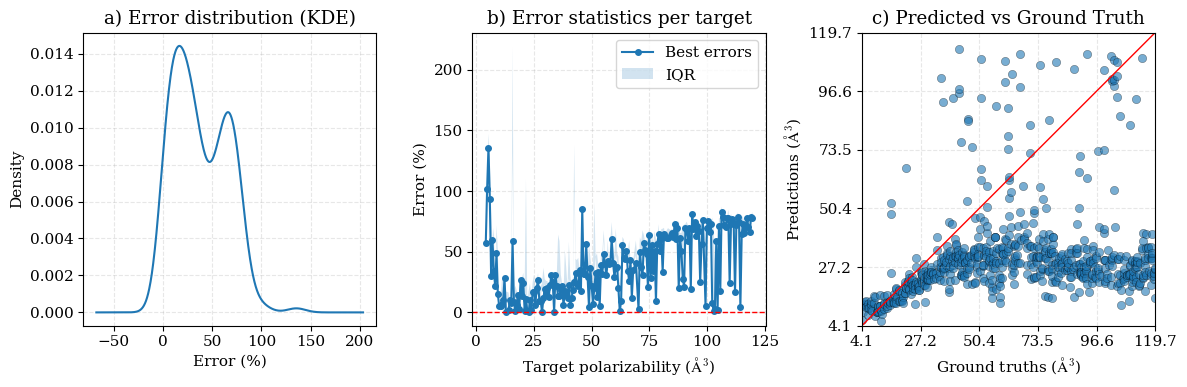

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Unit Conversion Factor
BOHR_TO_ANGSTROM3 = 0.14818471

# Load GPT-generated molecules
df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')

# --- 1. Apply Factor to Physical Columns ---
# Convert from Bohr^3 to Angstrom^3
df['static_polarizability_original'] = df['static_polarizability_original'] * BOHR_TO_ANGSTROM3
df['static_polarizability_pred_original'] = df['static_polarizability_pred_original'] * BOHR_TO_ANGSTROM3

# Convert error to percentage (Percentage is unitless, so no factor needed here)
df['error'] = abs(100 * df['error'])

# Aggregate error statistics per target polarizability
# (Grouping now happens on the Angstrom^3 values)
df_grouped = df.groupby('static_polarizability_original').min()
best_fitness = df.groupby("static_polarizability_original")["error"].min()
q1 = df.groupby("static_polarizability_original")["error"].quantile(0.25)
q3 = df.groupby("static_polarizability_original")["error"].quantile(0.75)
targets_sorted = sorted(df["static_polarizability_original"].unique())

# Set up figure
fig = plt.figure(figsize=(12, 4))

# --- Subplot (a): KDE of errors ---
plt.subplot(1, 3, 1)
df_grouped['error'].plot.kde()
plt.xlabel('Error (%)')
plt.title('a) Error distribution (KDE)')
plt.grid(True, linestyle='--', alpha=0.3)

# --- Subplot (b): Best and IQR of errors per target polarizability ---
plt.subplot(1, 3, 2)
plt.plot(targets_sorted, best_fitness.loc[targets_sorted], marker="o", markersize=4, label="Best errors")
plt.fill_between(targets_sorted, q1.loc[targets_sorted], q3.loc[targets_sorted], alpha=0.2, label="IQR")
plt.axhline(0, color="red", linestyle="--", linewidth=1)

# Updated Label with Unit
plt.xlabel(r"Target polarizability ($\mathrm{\AA}^3$)")
plt.ylabel("Error (%)")
plt.title("b) Error statistics per target")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# --- Subplot (c): Predicted vs. Target Polarizabilities ---
targets_expanded = df["static_polarizability_original"]
pred = df["static_polarizability_pred_original"]

plt.subplot(1, 3, 3)
plt.scatter(targets_expanded, pred, alpha=0.6, edgecolors='k', linewidth=0.3)

# Dynamic limits based on the new Angstrom values
min_val = min(targets_expanded.min(), pred.min())
max_val = max(targets_expanded.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r", linewidth=1)
plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

# Update ticks to match new range
plt.xticks(np.linspace(min_val, max_val, 6))
plt.yticks(np.linspace(min_val, max_val, 6))

# Updated Labels with Unit
plt.xlabel(r"Ground truths ($\mathrm{\AA}^3$)")
plt.ylabel(r"Predictions ($\mathrm{\AA}^3$)")
plt.title("c) Predicted vs Ground Truth")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig('../figures/Figure_22.pdf')

## 14. Analysis of Top 200 GPT-Generated Candidates

We focus on the **best-performing 200 molecules** generated by the GPT model (based on lowest prediction error) to evaluate:

1. **Prediction accuracy** compared to ground truth polarizabilities.  
2. **Polarizability distribution** relative to the original dataset.

Explanation:
- Subplot (a) shows predicted versus ground truth polarizabilities for the top 200 candidates. Points close to the diagonal indicate high prediction accuracy.
- Subplot (b) compares the distribution of polarizabilities between the original dataset and the top 200 GPT-generated molecules, showing how well the best candidates cover the property space.
- Computing R² for all molecules and for the top 200 provides a quantitative measure of model performance, highlighting the quality of the top candidates for property-guided polymer design.

R² (all GPT-generated molecules): -1.0532


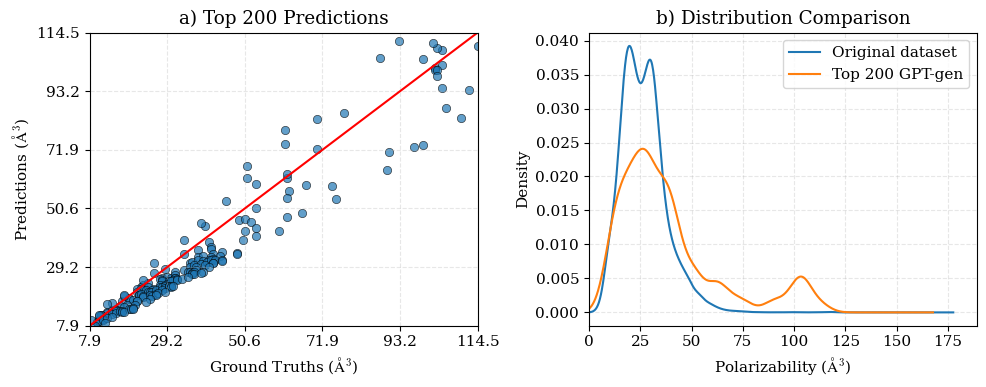

R² (Top 200 GPT-generated molecules): 0.8976


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Unit Conversion Factor
BOHR_TO_ANGSTROM3 = 0.14818471

# 1. Load Data
df = pd.read_csv('../polygraphpy/data/generative_output/generated_molecules.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')
df_original = df_original[df_original['chain_size'] == 0]

# 2. Apply Factor to Physical Columns (Convert Bohr^3 -> Angstrom^3)
# For the generated dataset
df['static_polarizability_original'] = df['static_polarizability_original'] * BOHR_TO_ANGSTROM3
df['static_polarizability_pred_original'] = df['static_polarizability_pred_original'] * BOHR_TO_ANGSTROM3

# For the reference original dataset
df_original['static_polarizability'] = df_original['static_polarizability'] * BOHR_TO_ANGSTROM3

# 3. Compute overall R² (on physical units)
r2_all = r2_score(df['static_polarizability_original'], df['static_polarizability_pred_original'])
print(f"R² (all GPT-generated molecules): {r2_all:.4f}")

# 4. Select top 200 candidates with lowest error
# Note: We check if 'error' is percentage or fraction in your file. 
# If your previous code multiplied by 100 in memory but not saved, this raw load might be fractional.
# We'll treat <= 0.35 (fraction) or <= 35 (percent) generally.
if df['error'].abs().max() <= 1.0:
    # Likely fractional
    df_top200 = df[df['error'].abs() <= 0.35].sort_values(by='error', key=abs)[:200]
else:
    # Likely percentage
    df_top200 = df[df['error'].abs() <= 35].sort_values(by='error', key=abs)[:200]

targets_expanded = df_top200["static_polarizability_original"]
pred = df_top200["static_polarizability_pred_original"]

# 5. Plot
fig = plt.figure(figsize=(10, 4))

# --- Subplot (a): Predicted vs. Ground Truth ---
plt.subplot(1, 2, 1)
plt.scatter(targets_expanded, pred, alpha=0.7, edgecolors='k', linewidth=0.5)

# Dynamic limits based on physical values
min_val = min(targets_expanded.min(), pred.min())
max_val = max(targets_expanded.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r", linewidth=1.5)
plt.xlim([min_val, max_val])
plt.ylim([min_val, max_val])

# Update ticks
plt.xticks(np.linspace(min_val, max_val, 6))
plt.yticks(np.linspace(min_val, max_val, 6))

plt.xlabel(r"Ground Truths ($\mathrm{\AA}^3$)")
plt.ylabel(r"Predictions ($\mathrm{\AA}^3$)")
plt.title("a) Top 200 Predictions")
plt.grid(True, linestyle='--', alpha=0.3)

# --- Subplot (b): Polarizability distribution ---
plt.subplot(1, 2, 2)

# Plot KDEs
df_original['static_polarizability'].plot.kde(bw_method=0.18, label='Original dataset')
df_top200['static_polarizability_original'].plot.kde(bw_method=0.18, label='Top 200 GPT-gen')

# Force x-axis to start at 0, keeping the dynamic upper limit
current_xlim = plt.xlim()
plt.xlim(left=0, right=current_xlim[1])

plt.xlabel(r'Polarizability ($\mathrm{\AA}^3$)')
plt.ylabel('Density')
plt.legend()
plt.title("b) Distribution Comparison")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('../figures/Figure_23.pdf')

# Compute R² for top 200 candidates
r2_top200 = r2_score(df_top200['static_polarizability_original'], df_top200['static_polarizability_pred_original'])
print(f"R² (Top 200 GPT-generated molecules): {r2_top200:.4f}")